In [ ]:
# import shutil
# from pathlib import Path
# import kagglehub

# owner = 'asad11914'
# dataset = 'coco-2017-keypoints'
# cache_path = kagglehub.dataset_download(f"{owner}/{dataset}")
# t_dir = Path('data/coco')
# t_dir.mkdir(parents=True, exist_ok=True)
# shutil.copytree(cache_path, t_dir, dirs_exist_ok=True)

In [ ]:
import json, random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
from pathlib import Path

IMG_DIR = './data/coco2017/train2017'
ANN_JSON = './data/coco2017/annotations/person_keypoints_train2017.json'
VAL_IMG_DIR = './data/coco2017/val2017'
VAL_ANN_JSON = './data/coco2017/annotations/person_keypoints_val2017.json'

COCO_KP_NAMES=[
    "nose","left_eye","right_eye",'left_ear','right_ear', "left_shoulder","right_shoulder", "left_elbow","right_elbow",
    "left_wrist","right_wrist","left_hip","right_hip","left_knee","right_knee","left_ankle","right_ankle"
]

limbs=[
    (5,7),(7,9),(6,8),(8,10), # arms
    (11,13),(13,15),(12,14),(14,16), # legs
    (5,6),(11,12),(5,11),(6,12), # torso
    (0,5), (0,6)
]

PALETTE=[
    (255,99,132), (54,162,235), (255,206,86), (75, 192, 192),
    (153,102,255),(255,156,64),(200,80,200), (80,200,120),
    (80,80,200), (200,200,80), (20,140,200), (200,40,20)
]

def load_coco_index(ann_json):
    with open(ann_json, 'r') as f:
        ann=json.load(f)
    id2file={im['id']:im['file_name'] for im in ann['images']}
    per_img={} # 현재는 사람 데이터만 있으므로 추후에 그대로 사용할 수 있도록 남겨둠
    for a in ann['annotations']:
        if a.get('num_keypoints',0) == 0:
            continue
        img_id=a['image_id']
        per_img.setdefault(img_id, []).append(a)
    return id2file, per_img
try: FONT = ImageFont.truetype('DejaVuSans.ttf')
except: FONT=None
def draw_kps_on_image(img_pil, instances, draw_skel, draw_points, draw_labels, point_radius):
    canvas=img_pil.copy()
    draw=ImageDraw.Draw(canvas)

    for idx, a in enumerate(instances):
        kps = np.array(a['keypoints']).reshape(-1,3) # (17, (x,y,v))
        color = PALETTE[idx % len(PALETTE)]

        if draw_skel:
            for (j1,j2) in limbs:
                x1, y1, v1 = kps[j1]
                x2, y2, v2 = kps[j2]
                if v1 > 0 and v2 > 0:
                    draw.line([(x1,y1), (x2,y2)], fill=color, width=3)
        for j, (x,y,v) in enumerate(kps):
            if v>0 and draw_points:
                r = point_radius
                draw.ellipse([(x-r, y-r), (x+y, y+r)], outline=(0,0,0), width=3)
                draw.ellipse([(x-r, y-r), (x+y, y+r)], outline=(0,255,0), width=2)
                if draw_labels:
                    name=COCO_KP_NAMES[j] if j < len(COCO_KP_NAMES) else f"kp{j}"
                    txt = f'{name}'

                    for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]:
                        draw.text((x+3, y-12), txt, fill=(255,255,255),font=FONT)
    return canvas

def collect_existing_samples(images_root, id2file, per_img):
    root=Path(images_root)
    items=[]
    for img_id, fname in id2file.items():
        if img_id not in per_img:
            continue
        p=root/fname
        if p.exists():
            items.append((img_id, str(p)))
    return items

def show_coco_keypoints_grid(images_root, ann_json, n=12, cols=4, shuffle=True, 
                             draw_skel=True, draw_points=True, draw_labels=True, figsize_per_cell=(4,4),
                            subset_ratio=1.0):
    id2file, per_img = load_coco_index(ann_json)
    sample=collect_existing_samples(images_root, id2file, per_img)

    if len(samples) == 0:
        print("표시할 샘플이 없습니다.")
    if subset_ratio < 1.0:
        k = max(i,int(len(samples)*subset_ratio))
        samples=random.sample(sample,k)
    if shuffle:
        random.shuffle(samples)
    samples=samples[:n]

    rows=int(np.ceil(len(samples)/cols))
    plt.figure(figsize=(cols*figsize_per_cell[0], rows*figsize_per_cell[1]))
    for i, (img_id, img_path) in enumerate(samples):
        img = Image.open(img_path).convert('RGB')

        instances = per_img[img_id]
        canvas = draw_kps_on_image(img, instances, draw_skel=draw_skel, draw_labels=draw_labels, draw_points=draw_points)

        ax = plt.subplot(rows, cols, i+1)
        ax.imshow(canvas)
        ax.axis('off')
        ax.set_title(Path(img_path).name, fontsize=9)
    plt.tight_layout()
    plt.show()

show_coco_keypoints_grid(
    images_root=IMG_DIR,
    ann_json=ANN_JSON,
)

# 여기부터

In [2]:
# openpose
import os, math, random, json
from pathlib import Path

import numpy as np
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.transforms import functional as TF
import matplotlib as mpl
# from torchvision.utils import 

# 이미지 준비
IMG_DIR = './data/coco2017/train2017'
ANN_JSON = './data/coco2017/annotations/person_keypoints_train2017.json'
VAL_IMG_DIR = './data/coco2017/val2017'
VAL_ANN_JSON = './data/coco2017/annotations/person_keypoints_val2017.json'
OUT_DIR = './ran_openpose_lab'

IMG_SIZE = 368 # 이미지 크기
OUT_STRIDE = 8 # 라벨 해상도(다운샘플 비율)
HM_SIGMA = 2.0 # 히트맵 가우시안 SIGMA
PAE_THICKNESS = 2 # PAF 굵기(다운샘플 그리도 기준)

BATCH_SIZE = 8
EPOCHS = 3
LR = 1e-3
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 4

# 원래는 이렇게 안함 7:3, 8:2정도의 비율임
SUBSET_RATIO = 0.05 # 학습 데이터 비율
VAL_RATIO = 0.05 # 검증 데이터 비율

SEED = 42
AMP = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.makedirs(OUT_DIR, exist_ok=True)

In [3]:
# 재현성을 위한 시드 설정
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(SEED)

COCO_KP_NAMES=[
    "nose","left_eye","right_eye",'left_ear','right_ear', "left_shoulder","right_shoulder", "left_elbow","right_elbow",
    "left_wrist","right_wrist","left_hip","right_hip","left_knee","right_knee","left_ankle","right_ankle"
]

limbs=[
    (5,7),(7,9),(6,8),(8,10), # arms
    (11,13),(13,15),(12,14),(14,16), # legs
    (5,6),(11,12),(5,11),(6,12), # torso
    (0,5), (0,6)
]

In [4]:
# 라벨 정리(히트맵/PAF)
def draw_gaussian(heatmap, center, sigma, conf=1.0):
    # 키포인트 값을 가우시안 구간으로 적용(다운샘플 그리드 기준)
    x, y = center
    H, W = heatmap.shape
    if x < 0 or y < 0 or x >= W or y >= H:
        return heatmap
    r = int(3*sigma)
    x0, x1 = max(0, x-r), min(W-1, x+r)
    y0, y1 = max(0, y-r), min(H-1, y+r)
    xs = np.arange(x0, x1+1)
    ys = np.arange(y0, y1+1)
    yy, xx = np.meshgrid(ys, xs, indexing='ij')
    d2 = (xx-x) ** 2 + (yy-y) ** 2
    g = np.exp(-d2/(2*sigma**2)) ** conf
    heatmap[y0:y1+1, x0:x1+1] = np.maximum(heatmap[y0:y1+1, x0:x1+1], g)
    return heatmap

def put_paf(paf_x, paf_y, a, b, thickness=1):
    H, W = paf_x.shape
    ax, ay = a
    bx, by = b
    vx, vy = bx-ax, by-ay
    norm = math.hypot(vx, vy)
    if norm < 1e-3:
        return np.zeros((H,W), np.float32)
    vx /= norm
    vy /= norm

    minx = max(int(min(ax, bx)-thickness), 0)
    maxx = min(int(max(ax, bx)+thickness), W-1)
    miny = max(int(min(ay, by)-thickness), 0)
    maxy = min(int(max(ay, by)+thickness), H-1)

    count = np.zeros((H,W), np.float32)

    for y in range(miny, maxy+1):
        for x in range(minx, maxx+1):
            rx, ry = x-ax, y-ay
            t = rx*vx + ry*vy
            if t < 0 or t > norm:
                continue
            px, py = ax+t*vx, ay+t*vy
            if math.hypot(x-px, y-py) <= thickness:
                paf_x[y,x] += vx
                paf_y[y,x] += vy
                count[y,x] += 1
    return count

In [5]:
# dataset
class COCOPoseDataset(Dataset):
    def __init__(self, images_dir, ann_json, img_size=IMG_SIZE, out_stride=OUT_STRIDE,
                 sigma=HM_SIGMA, paf_thickness=PAE_THICKNESS, subset_ratio=SUBSET_RATIO, random_flip=True):
        super().__init__()
        self.images_dir = Path(images_dir)
        self.img_size = img_size
        self.out_stride = out_stride
        self.hm_sigma = sigma
        self.paf_th = paf_thickness
        self.random_flip = random_flip

        with open(ann_json, 'r') as f:
            ann = json.load(f)
        id2file = {im['id']: im['file_name'] for im in ann['images']}
        per_img = {}
        for a in ann['annotations']:
            if a.get('iscrwd', 0) == 1:
                continue
            if a.get('num_keypoints', 0) == 0:
                continue
            per_img.setdefault(a['image_id'], []).append(a)
        items = [(img_id, id2file[img_id], per_img[img_id]) for img_id in per_img]
        if subset_ratio < 1.0:
            k = max(1, int(len(items)*subset_ratio))
            items = random.sample(items, k)
        self.items = items

    def __len__(self):
        return len(self.items)
    def __getitem__(self, idx):
        img_id, file_name, anns = self.items[idx]
        img_path = self.images_dir/file_name

        img = Image.open(img_path).convert('RGB')
        w0, h0 = img.size
        img = TF.resize(img, [self.img_size, self.img_size], interpolation=TF.InterpolationMode.BILINEAR)
        img_np = np.array(img)
        flip = self.random_flip and (random.random() < 0.5)
        if flip:
            img_np = img_np[:, ::-1, :].copy()
        
        H = W = self.img_size
        oh, ow = H//self.out_stride, W//self.out_stride
        n_kp = len(COCO_KP_NAMES)
        n_l = len(limbs)
        heatmaps = np.zeros((n_kp, oh, ow), np.float32)
        pafs = np.zeros((n_l*2, oh, ow), np.float32)
        paf_cnt = np.zeros((n_l, oh, ow), np.float32)

        sx, sy = W/w0, H/h0
        for a in anns:
            kps = np.array(a['keypoints']).reshape(-1, 3)
            # 히트맵 영역 처리
            for j in range(n_kp):
                x,y,v = kps[j]
                if v > 0:
                    x, y = int(x*sx), int(y*sy)
                    if flip: x = W-1-x
                    xs = int(round(x/self.out_stride))
                    ys = int(round(y/self.out_stride))
                    if 0 <= xs < ow and 0 <= ys < oh:
                        draw_gaussian(heatmaps[j], (xs, ys), self.hm_sigma)
            # PAF 처리
            for li, (j1, j2) in enumerate(limbs):
                x1, y1, v1 = kps[j1]
                x2, y2, v2 = kps[j2]
                if v1 > 0 and v2 > 0:
                    x1, y1 = x1*sx, y1*sy
                    x2, y2 = x2*sx, y2*sy
                    if flip:
                        x1 = W-1-x1
                        x2 = W-1-x2
                    ax, ay = x1/self.out_stride, y1/self.out_stride
                    bx, by = x2/self.out_stride, y2/self.out_stride
                    cnt = put_paf(pafs[2*li], pafs[2*li+1], (ax, ay), (bx, by), thickness=self.paf_th)
                    paf_cnt[li] += cnt
        for li in range(n_l):
            mask = paf_cnt[li] > 0
            if mask.any():
                pafs[2*li][mask] /= paf_cnt[li][mask]
                pafs[2*li+1][mask] /= paf_cnt[li][mask]
        hm_mask = np.ones_like(heatmaps,np.float32)
        paf_mask= np.ones_like(pafs,np.float32)

        img_t=torch.from_numpy(img_np).permute(2,0,1).float()/255.0
        img_t = TF.normalize(img_t,[0.485,0.456,0.406],[0.229,0.224,0.225])
        return{
            'image':img_t,
            'heatmap': torch.from_numpy(heatmaps),
            'pafs': torch.from_numpy(pafs),
            'hm_mask': torch.from_numpy(hm_mask),
            'paf_mask': torch.from_numpy(paf_mask),
            'meta':{'img_id':img_id, 'file':str(img_path)}
        }

In [6]:
class SimplePoseNet(nn.Module):
    def __init__(self, n_keypoints=17, n_limbs=len(limbs)):
        super().__init__()
        bb=torchvision.models.resnet18(weights=None)
        self.stem = nn.Sequential( # bb에 들어있는 레이어 및 구조를 일부 가져와서 활용
            bb.conv1,
            bb.bn1,
            bb.relu,
            bb.maxpool, # stride=4
            bb.layer1,  # stride=4
            bb.layer2,  # stride=8
        )
        self.refine = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.hm_head = nn.Sequential(
            nn.Conv2d(256, 128, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, n_keypoints, 1),
        )
        self.paf_head = nn.Sequential(
            nn.Conv2d(256, 128, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, n_limbs*2, 1),
        )

    def forward(self, x):
        f = self.stem(x)
        f = self.refine(f)
        hm = self.hm_head(f)   # [B, K, H/8, W/8]
        paf = self.paf_head(f) # [B, 2*L, H/8, W/8]
        return hm, paf

In [7]:
# class
class PoseLoss(nn.Module):
    def __init__(self, hm_w=1.0, paf_w=1.0):
        super().__init__()
        self.hm_w = hm_w
        self.paf_w = paf_w

    def forward(self, phm, ppaf, ghm, gpaf, hm_mask, paf_mask):
        hm_loss = ((phm-ghm) ** 2 * hm_mask).mean()
        paf_loss = ((ppaf-gpaf) ** 2 * paf_mask).mean()
        loss = hm_loss*self.hm_w + paf_loss*self.paf_w
        return loss, hm_loss.detach(), paf_loss.detach()

In [8]:
def _denorm_img(x):
    mean = torch.tensor([0.485, 0.456, 0.406], device=x.device)[:, None, None]
    std = torch.tensor([0.229, 0.224, 0.225], device=x.device)[:, None, None]
    return (x*std+mean).clamp(0,1)

def _colorize(gray_np, cmap_name='jet'):
    g = gray_np.astype(np.float32)
    g = (g-g.min())/(g.max()-g.min()+1e-6)
    cmap = mpl.colormaps.get_cmap(cmap_name)
    rgb = cmap(g)[...,:3]
    return (rgb*255).astype(np.uint8)

def _overlay(img_np, hm_rgb, alpha=0.45):
    H, W = img_np.shape[:2]
    if hm_rgb.shape[:2] != (H,W):
        hm_rgb=np.array(Image.fromarray(hm_rgb).resize((W,H), Image.BILINEAR))
    base = (img_np*255).astype(np.uint8)
    over = (hm_rgb.astype(np.float32) + (1-alpha) * base.astype(np.float32)).clip(0,255).astype(np.uint8)
    return over

In [9]:
def get_loaders():
    tr_ds = COCOPoseDataset(
        IMG_DIR, ANN_JSON,
        img_size=IMG_SIZE, out_stride=OUT_STRIDE, sigma=HM_SIGMA, paf_thickness=PAE_THICKNESS,
        subset_ratio=SUBSET_RATIO, random_flip=True
    )
    val_ds= COCOPoseDataset(
        VAL_IMG_DIR, VAL_ANN_JSON,
        img_size=IMG_SIZE, out_stride=OUT_STRIDE, sigma=HM_SIGMA, paf_thickness=PAE_THICKNESS,
        subset_ratio=min(1.0,VAL_RATIO), random_flip=False
    )
    tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True, pin_memory=torch.cuda.is_available())
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=torch.cuda.is_available())
    return tr_ds, val_ds, tr_loader, val_loader

def build_all():
    tr_ds, val_ds, tr_loader, val_loader = get_loaders()
    model = SimplePoseNet(n_keypoints=len(COCO_KP_NAMES), n_limbs=len(limbs)).to(DEVICE)
    criterion = PoseLoss(hm_w=1.0, paf_w=1.0)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    scaler = torch.torch.amp.GradScaler('cuda', enabled=AMP and torch.cuda.is_available())
    return tr_ds, val_ds, tr_loader, val_loader, model, criterion, opt, scheduler, scaler

In [10]:
def train_one_epoch(m, loader, criterion, opt, scaler, epoch):
    m.train()
    run = 0.0
    pbar = tqdm(loader, desc=f'학습 {epoch}', total=len(loader), leave=False)
    for batch in pbar:
        img = batch['image'].to(DEVICE, non_blocking=True)
        ghm = batch['heatmap'].to(DEVICE, non_blocking=True)
        gpaf = batch['pafs'].to(DEVICE, non_blocking=True)
        hmm = batch['hm_mask'].to(DEVICE, non_blocking=True)
        pafm = batch['paf_mask'].to(DEVICE, non_blocking=True)

        opt.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=AMP and torch.cuda.is_available()):
            phm, ppaf = m(img)
            loss, hm_l, paf_l = criterion(phm, ppaf, ghm, gpaf, hmm, pafm)
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()

        run += loss.item() * img.size(0)
        pbar.set_postfix(loss=f'{loss.item():.4f}', hm=f'{hm_l.item():.4f}', paf=f'{paf_l.item():.4f}')
    return run / len(loader.dataset)

@torch.no_grad()
def validate_and_vis(m, loader, epoch, max_batches=1):
    out_vis = os.path.join(OUT_DIR, f'val_{epoch:03d}')
    os.makedirs(out_vis, exist_ok=True)
    it = iter(loader)
    for bi in range(max_batches):
        try: batch = next(it)
        except StopIteration: break
        imgs = batch['image'].to(DEVICE)
        phm, _ = m(imgs)
        phm = torch.sigmoid(phm)
        B = imgs.size(0)
        for i in range(B):
            img_np = _denorm_img(imgs[i]).permute(1,2,0).cpu().numpy()
            hm_np = phm[i].detach().cpu().numpy()
            hm_max = hm_np.max(axis=0)
            hm_rgb = _colorize(hm_max)
            over = _overlay(img_np, hm_rgb, alpha=0.45)
            Image.fromarray(over).save(os.path.join(out_vis, f'vis_{bi:02d}_{i:02d}.png'))

In [11]:
tr_ds, val_ds, tr_loader, val_loader, m, criterion, opt, scheduler, scaler = build_all()

In [12]:
for ep in range(1, EPOCHS+1):
    tr_loss = train_one_epoch(m, tr_loader, criterion, opt, scaler, ep)
    scheduler.step()
    validate_and_vis(m, val_loader, ep)
    torch.save({'model':m.state_dict(), 'epoch':ep}, os.path.join(OUT_DIR, f'ck_m_{ep:03d}.pt'))
    print(f'[{ep:02d}/{EPOCHS}] tr_loss:{tr_loss:.4f}')

KeyboardInterrupt: 

In [13]:
import os, math, random, json
from pathlib import Path

import numpy as np
from PIL import Image, ImageDraw, ImageFont
from tqdm import tqdm

import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import clear_output

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.transforms import functional as TF

IMG_DIR = './data/coco2017/train2017'
ANN_JSON = './data/coco2017/annotations/person_keypoints_train2017.json'
VAL_IMG_DIR = './data/coco2017/val2017'
VAL_ANN_JSON = './data/coco2017/annotations/person_keypoints_val2017.json'


IMG_SIZE = 368 # 이미지 크기
OUT_STRIDE = 8 # 라벨 해상도(다운샘플 비율)
HM_SIGMA = 2.0 # 히트맵 가우시안 SIGMA
PAE_THICKNESS = 2 # PAF 굵기(다운샘플 그리도 기준)

BATCH_SIZE = 8
EPOCHS = 30
LR = 1e-3
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 4

# 원래는 이렇게 안함 7:3, 8:2정도의 비율임
SUBSET_RATIO = 0.05 
VAL_RATIO = 0.05 

SEED = 42
AMP = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [14]:
# 상수 정리
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(SEED)

COCO_KP_NAMES=[
    "nose","left_eye","right_eye",'left_ear','right_ear', "left_shoulder","right_shoulder", "left_elbow","right_elbow",
    "left_wrist","right_wrist","left_hip","right_hip","left_knee","right_knee","left_ankle","right_ankle"
]

limbs=[
    (5,7),(7,9),(6,8),(8,10), # arms
    (11,13),(13,15),(12,14),(14,16), # legs
    (5,6),(11,12),(5,11),(6,12), # torso
    (0,5), (0,6)
]

In [15]:
# 라벨 유틸 정리
def draw_gaussian(heatmap, center, sigma, conf=1.0):
    # 키포인트 값을 가우시안 구간으로 적용(다운샘플 그리드 기준)
    x, y = center
    H, W = heatmap.shape
    if x < 0 or y < 0 or x >= W or y >= H:
        return heatmap
    r = int(3*sigma)
    x0, x1 = max(0, x-r), min(W-1, x+r)
    y0, y1 = max(0, y-r), min(H-1, y+r)
    xs = np.arange(x0, x1+1)
    ys = np.arange(y0, y1+1)
    yy, xx = np.meshgrid(ys, xs, indexing='ij')
    d2 = (xx-x) ** 2 + (yy-y) ** 2
    g = np.exp(-d2/(2*sigma**2)) ** conf
    heatmap[y0:y1+1, x0:x1+1] = np.maximum(heatmap[y0:y1+1, x0:x1+1], g)
    return heatmap

def put_paf(paf_x, paf_y, a, b, thickness=1):
    H, W = paf_x.shape
    ax, ay = a
    bx, by = b
    vx, vy = bx-ax, by-ay
    norm = math.hypot(vx, vy)
    if norm < 1e-3:
        return np.zeros((H,W), np.float32)
    vx /= norm
    vy /= norm

    minx = max(int(min(ax, bx)-thickness), 0)
    maxx = min(int(max(ax, bx)+thickness), W-1)
    miny = max(int(min(ay, by)-thickness), 0)
    maxy = min(int(max(ay, by)+thickness), H-1)

    count = np.zeros((H,W), np.float32)

    for y in range(miny, maxy+1):
        for x in range(minx, maxx+1):
            rx, ry = x-ax, y-ay
            t = rx*vx + ry*vy
            if t < 0 or t > norm:
                continue
            px, py = ax+t*vx, ay+t*vy
            if math.hypot(x-px, y-py) <= thickness:
                paf_x[y,x] += vx
                paf_y[y,x] += vy
                count[y,x] += 1
    return count

In [16]:
# 데이터 정리
class COCOPoseDataset(Dataset):
    def __init__(self, images_dir, ann_json, img_size=IMG_SIZE, out_stride=OUT_STRIDE,
                 sigma=HM_SIGMA, paf_thickness=PAE_THICKNESS, subset_ratio=SUBSET_RATIO, random_flip=True):
        super().__init__()
        self.images_dir = Path(images_dir)
        self.img_size = img_size
        self.out_stride = out_stride
        self.hm_sigma = sigma
        self.paf_th = paf_thickness
        self.random_flip = random_flip

        with open(ann_json, 'r') as f:
            ann = json.load(f)
        id2file = {im['id']: im['file_name'] for im in ann['images']}
        per_img = {}
        for a in ann['annotations']:
            if a.get('iscrwd', 0) == 1:
                continue
            if a.get('num_keypoints', 0) == 0:
                continue
            per_img.setdefault(a['image_id'], []).append(a)
        items = [(img_id, id2file[img_id], per_img[img_id]) for img_id in per_img]
        if subset_ratio < 1.0:
            k = max(1, int(len(items)*subset_ratio))
            items = random.sample(items, k)
        self.items = items

    def __len__(self):
        return len(self.items)
    def __getitem__(self, idx):
        img_id, file_name, anns = self.items[idx]
        img_path = self.images_dir/file_name

        img = Image.open(img_path).convert('RGB')
        w0, h0 = img.size
        img = TF.resize(img, [self.img_size, self.img_size], interpolation=TF.InterpolationMode.BILINEAR)
        img_np = np.array(img)
        flip = self.random_flip and (random.random() < 0.5)
        if flip:
            img_np = img_np[:, ::-1, :].copy()
        
        H = W = self.img_size
        oh, ow = H//self.out_stride, W//self.out_stride
        n_kp = len(COCO_KP_NAMES)
        n_l = len(limbs)
        heatmaps = np.zeros((n_kp, oh, ow), np.float32)
        pafs = np.zeros((n_l*2, oh, ow), np.float32)
        paf_cnt = np.zeros((n_l, oh, ow), np.float32)

        sx, sy = W/w0, H/h0
        for a in anns:
            kps = np.array(a['keypoints']).reshape(-1, 3)
            # 히트맵 영역 처리
            for j in range(n_kp):
                x,y,v = kps[j]
                if v > 0:
                    x, y = int(x*sx), int(y*sy)
                    if flip: x = W-1-x
                    xs = int(round(x/self.out_stride))
                    ys = int(round(y/self.out_stride))
                    if 0 <= xs < ow and 0 <= ys < oh:
                        draw_gaussian(heatmaps[j], (xs, ys), self.hm_sigma)
            # PAF 처리
            for li, (j1, j2) in enumerate(limbs):
                x1, y1, v1 = kps[j1]
                x2, y2, v2 = kps[j2]
                if v1 > 0 and v2 > 0:
                    x1, y1 = x1*sx, y1*sy
                    x2, y2 = x2*sx, y2*sy
                    if flip:
                        x1 = W-1-x1
                        x2 = W-1-x2
                    ax, ay = x1/self.out_stride, y1/self.out_stride
                    bx, by = x2/self.out_stride, y2/self.out_stride
                    cnt = put_paf(pafs[2*li], pafs[2*li+1], (ax, ay), (bx, by), thickness=self.paf_th)
                    paf_cnt[li] += cnt
        for li in range(n_l):
            mask = paf_cnt[li] > 0
            if mask.any():
                pafs[2*li][mask] /= paf_cnt[li][mask]
                pafs[2*li+1][mask] /= paf_cnt[li][mask]
        hm_mask = np.ones_like(heatmaps,np.float32)
        paf_mask= np.ones_like(pafs,np.float32)

        img_t=torch.from_numpy(img_np).permute(2,0,1).float()/255.0
        img_t = TF.normalize(img_t,[0.485,0.456,0.406],[0.229,0.224,0.225])
        return{
            'image':img_t,
            'heatmap': torch.from_numpy(heatmaps),
            'pafs': torch.from_numpy(pafs),
            'hm_mask': torch.from_numpy(hm_mask),
            'paf_mask': torch.from_numpy(paf_mask),
            'meta':{'img_id':img_id, 'file':str(img_path)}
        }

In [17]:
# 모델 정리
class SimplePoseNet(nn.Module):
    def __init__(self, n_keypoints=17, n_limbs=len(limbs)):
        super().__init__()
        bb=torchvision.models.resnet18(weights=None)
        self.stem = nn.Sequential( # bb에 들어있는 레이어 및 구조를 일부 가져와서 활용
            bb.conv1,
            bb.bn1,
            bb.relu,
            bb.maxpool, # stride=4
            bb.layer1,  # stride=4
            bb.layer2,  # stride=8
        )
        self.refine = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.hm_head = nn.Sequential(
            nn.Conv2d(256, 128, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, n_keypoints, 1),
        )
        self.paf_head = nn.Sequential(
            nn.Conv2d(256, 128, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, n_limbs*2, 1),
        )

    def forward(self, x):
        f = self.stem(x)
        f = self.refine(f)
        hm = self.hm_head(f)   # [B, K, H/8, W/8]
        paf = self.paf_head(f) # [B, 2*L, H/8, W/8]
        return hm, paf

In [18]:
# 손실 정리
class PoseLoss(nn.Module):
    def __init__(self, hm_w=1.0, paf_w=1.0):
        super().__init__()
        self.hm_w = hm_w
        self.paf_w = paf_w

    def forward(self, phm, ppaf, ghm, gpaf, hm_mask, paf_mask):
        hm_loss = ((phm-ghm) ** 2 * hm_mask).mean()
        paf_loss = ((ppaf-gpaf) ** 2 * paf_mask).mean()
        loss = hm_loss*self.hm_w + paf_loss*self.paf_w
        return loss, hm_loss.detach(), paf_loss.detach()

In [19]:
# 시각화 정리
try: 
    FONT = ImageFont.truetype('DejaVuSans.ttf', 12)
except:
    FONT = None

PALETTE=[
    (255,99,132), (54,162,235), (255,206,86), (75, 192, 192),
    (153,102,255),(255,156,64),(200,80,200), (80,200,120),
    (80,80,200), (200,200,80), (20,140,200), (200,40,20)
]

def _denorm_img(x):
    mean = torch.tensor([0.485, 0.456, 0.406], device=x.device)[:, None, None]
    std = torch.tensor([0.229, 0.224, 0.225], device=x.device)[:, None, None]
    return (x*std+mean).clamp(0,1)

def _colorize(gray_np, cmap_name='jet'):
    g = gray_np.astype(np.float32)
    g = (g-g.min())/(g.max()-g.min()+1e-6)
    cmap = mpl.colormaps.get_cmap(cmap_name)
    rgb = cmap(g)[...,:3]
    return (rgb*255).astype(np.uint8)

def _overlay(img_np, hm_rgb, alpha=0.45):
    H, W = img_np.shape[:2]
    if hm_rgb.shape[:2] != (H,W):
        hm_rgb=np.array(Image.fromarray(hm_rgb).resize((W,H), Image.BILINEAR))
    base = (img_np*255).astype(np.uint8)
    over = (hm_rgb.astype(np.float32) + (1-alpha) * base.astype(np.float32)).clip(0,255).astype(np.uint8)
    return over

In [34]:
# 피크단 연결
TH_HM_PEAK = 0.2
NMS_KERNEL = 3
PAF_SAMPLES = 10
PAF_THRESH = 0.05
MAX_PEAKS = 50

def _nms_2d(hm, k=3):
    from numpy.lib.stride_tricks import as_strided
    H,W = hm.shape
    pad = k//2
    p = np.pad(hm, ((pad,pad), (pad, pad)), mode='constant')
    shape = (H,W,k,k)
    strides = (p.strides[0], p.strides[1], p.strides[0], p.strides[1])
    windows = as_strided(p, shape=shape, strides=strides)
    mx = windows.max(axis=(2,3))
    return hm == mx

def find_peaks_from_heatmaps(hm, th=TH_HM_PEAK, nms_k=NMS_KERNEL, max_peaks=MAX_PEAKS):
    K, h, w = hm.shape
    out = []
    for k in range(K):
        m = hm[k].astype(np.float32)
        keep = _nms_2d(m, k=nms_k)
        ys, xs = np.where((m>=th) & keep)
        scores = m[ys, xs]
        if len(xs) > max_peaks:
            idx = np.argsort(-scores)[:max_peaks]
            xs, ys, scores = xs[idx], ys[idx], scores[idx]
        out.append([(int(x), int(y), float(s)) for x,y,s in zip(xs,ys,scores)])
    return out

def sample_paf_along_line(paf_xy, a, b, num=PAF_SAMPLES):
    vx, vy = b[0]-a[0], b[1]-a[1]
    norm = math.hypot(vx,vy)
    if norm < 1e-6:
        return 0.0
    vx /= norm
    vy /= norm

    xs = np.linspace(a[0], b[0], num=num)
    ys = np.linspace(a[1], b[1], num=num)
    px, py = paf_xy[0], paf_xy[1]

    H,W = px.shape
    dots = []

    for x,y in zip(xs,ys):
        xi, yi = int(round(x)), int(round(y))
        if 0<xi<W and 0<yi<H:
            ux, uy = px[yi, xi], py[yi, xi]
            un = math.hypot(ux, uy)
            if un > 1e-6:
                ux /= un
                uy /= un
                dots.append(ux*vx+uy*vy)
    return float(np.mean(dots)) if len(dots) > 0 else 0.0

def greedy_connect_limbs(peaks_per_k, pafs, limbs=limbs, paf_th=PAF_THRESH):
    assigned = {}
    for li, (j1,j2) in enumerate(limbs):
        paf_xy = pafs[2*li: 2*li+2]
        best = None
        peaks_per_k[j1]
        for a in peaks_per_k[j1]:
            for b in peaks_per_k[j2]:
                sim = sample_paf_along_line(paf_xy, (a[0], a[1]), (b[0], b[1]))
                if sim >= paf_th:
                    score = 0.5 * (a[2]+b[2]) + sim
                    if (best is None) or (score > best[0]):
                        best = (score, a, b)

        if best is not None:
            _, A, B = best
            assigned[j1] = (A[0], A[1], A[2])
            assigned[j2] = (B[0], B[1], B[2])
    return assigned

def draw_skeleton_overlay(base_rgb, hm_np, paf_np, limbs=limbs, out_stride=OUT_STRIDE,
                          th_peak=TH_HM_PEAK, nms_k=NMS_KERNEL, paf_thr=PAF_THRESH,
                          alpha_hm=0.35, cmap_name='jet', draw_points=True,draw_lines=True,draw_labels=True):
    hm_max=hm_np.max(axis=0)
    hm_rgb=_colorize(hm_max, cmap_name=cmap_name)
    over = _overlay(base_rgb, hm_rgb, alpha=alpha_hm)
    canvas = Image.fromarray(over)
    draw = ImageDraw.Draw(canvas)

    peaks = find_peaks_from_heatmaps(hm_np, th=th_peak, nms_k=nms_k)
    assigned = greedy_connect_limbs(peaks, paf_np, limbs=limbs, paf_th=paf_thr)

    if draw_lines:
        for idx, (j1,j2) in enumerate(limbs):
            if (j1 in assigned) and (j2 in assigned):
                color = PALETTE[idx%len(PALETTE)]
                x1 = assigned[j1][0] * out_stride
                x2 = assigned[j2][0] * out_stride
                y1 = assigned[j1][1] * out_stride
                y2 = assigned[j2][1] * out_stride
                draw.line([(x1,y1), (x2,y2)], fill=color, width=3)
    if draw_points or draw_labels:
        for ki, (xh,yh,sc) in assigned.items():
            x, y = xh*out_stride, yh*out_stride
            if draw_points:
                r=4
                draw.ellipse([(x-r, y-r), (x+r, y+r)], outline=(0,0,0), width=3)
                draw.ellipse([(x-r, y-r), (x+r, y+r)], outline=(0,255,0), width=3)
            if draw_labels:
                name = COCO_KP_NAMES[ki] if ki < len(COCO_KP_NAMES) else f'kp{ki}'
                txt = f'{name}:{sc:.2f}'
                for dx,dy in [(-1,0),(1,0),(0,-1),(0,1)]:
                    draw.text((x+3+dx, y-12+dy), txt, fill=(0,0,0), font=FONT)
                draw.text((x+3, y-12), txt, fill=(255,255,255), font=FONT)
    return canvas

In [35]:
# 이미지 표현(추론)
@torch.no_grad()
def visualize_batch_inline(m, loader, device, max_batches=1, max_images=8, th_peak=0.2, nms_k=3,
                           paf_thr=0.05, alpha_hm=0.35, cmap_name='jet', cols=4, epoch=None, title_prefix='VAL'):
    m.eval()
    it = iter(loader)

    try: clear_output(wait=True)
    except: pass

    canvases, names = [], []
    batches_done, got = 0, 0

    while batches_done < max_batches and got < max_images:
        try:
            batch = next(it)
        except StopIteration:
            break
        imgs = batch['image'].to(device)
        phm, ppaf = m(imgs)
        phm = torch.sigmoid(phm)
        B = imgs.size(0)

        for i in range(B):
            if got>=max_images:
                break
            base = _denorm_img(imgs[i]).permute(1,2,0).cpu().numpy()
            hmnp = phm[i].detach().cpu().numpy()
            pnp = ppaf[i].detach().cpu().numpy()
            canv = draw_skeleton_overlay(base, hmnp, pnp, limbs, OUT_STRIDE, th_peak, nms_k,paf_thr, alpha_hm, cmap_name, True, True, True)
            canvases.append(canv)
            name = batch['meta']['file'][i] if isinstance(batch['meta']['file'], list) else batch['meta']['file']
            names.append(Path(name).name if name else f'sample_{got:02d}')
            got += 1

        batches_done += 1
    if len(canvases) == 0:
        print('출력 내용 없음')
        return
    
    row = math.ceil(len(canvases)/cols)
    plt.figure(figsize=(cols*4, row*4))
    for idx, im in enumerate(canvases):
        ax = plt.subplot(row, cols, idx+1)
        ax.imshow(im)
        ax.axis('off')
        ax.set_title(names[idx], fontsize=10)
    supt = f'{title_prefix} - epoch{epoch}' if epoch is not None else f'{title_prefix}'
    plt.suptitle(supt, fontsize=14)
    plt.tight_layout()
    plt.show()

In [36]:
# 모델 학습 및 동작
def get_loaders():
    tr_ds = COCOPoseDataset(
        IMG_DIR, ANN_JSON,
        img_size=IMG_SIZE, out_stride=OUT_STRIDE, sigma=HM_SIGMA, paf_thickness=PAE_THICKNESS,
        subset_ratio=SUBSET_RATIO, random_flip=True
    )
    val_ds= COCOPoseDataset(
        VAL_IMG_DIR, VAL_ANN_JSON,
        img_size=IMG_SIZE, out_stride=OUT_STRIDE, sigma=HM_SIGMA, paf_thickness=PAE_THICKNESS,
        subset_ratio=min(1.0,VAL_RATIO), random_flip=False
    )
    tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True, pin_memory=torch.cuda.is_available())
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=torch.cuda.is_available())
    return tr_ds, val_ds, tr_loader, val_loader

def build_all():
    tr_ds, val_ds, tr_loader, val_loader = get_loaders()
    model = SimplePoseNet(n_keypoints=len(COCO_KP_NAMES), n_limbs=len(limbs)).to(DEVICE)
    criterion = PoseLoss(hm_w=1.0, paf_w=1.0)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    scaler = torch.torch.amp.GradScaler('cuda', enabled=AMP and torch.cuda.is_available())
    return tr_ds, val_ds, tr_loader, val_loader, model, criterion, opt, scheduler, scaler

def train_one_epoch(m, loader, criterion, opt, scaler, epoch):
    m.train()
    run = 0.0
    # n = 0
    pbar = tqdm(loader, desc=f'학습 {epoch}', total=len(loader), leave=False)
    for batch in pbar:
        img = batch['image'].to(DEVICE, non_blocking=True)
        ghm = batch['heatmap'].to(DEVICE, non_blocking=True)
        gpaf = batch['pafs'].to(DEVICE, non_blocking=True)
        hmm = batch['hm_mask'].to(DEVICE, non_blocking=True)
        pafm = batch['paf_mask'].to(DEVICE, non_blocking=True)

        opt.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=AMP and torch.cuda.is_available()):
            phm, ppaf = m(img)
            loss, hm_l, paf_l = criterion(phm, ppaf, ghm, gpaf, hmm, pafm)
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()

        run += loss.item() * img.size(0)
        pbar.set_postfix(loss=f'{loss.item():.4f}', hm=f'{hm_l.item():.4f}', paf=f'{paf_l.item():.4f}')
    return run / len(loader.dataset)

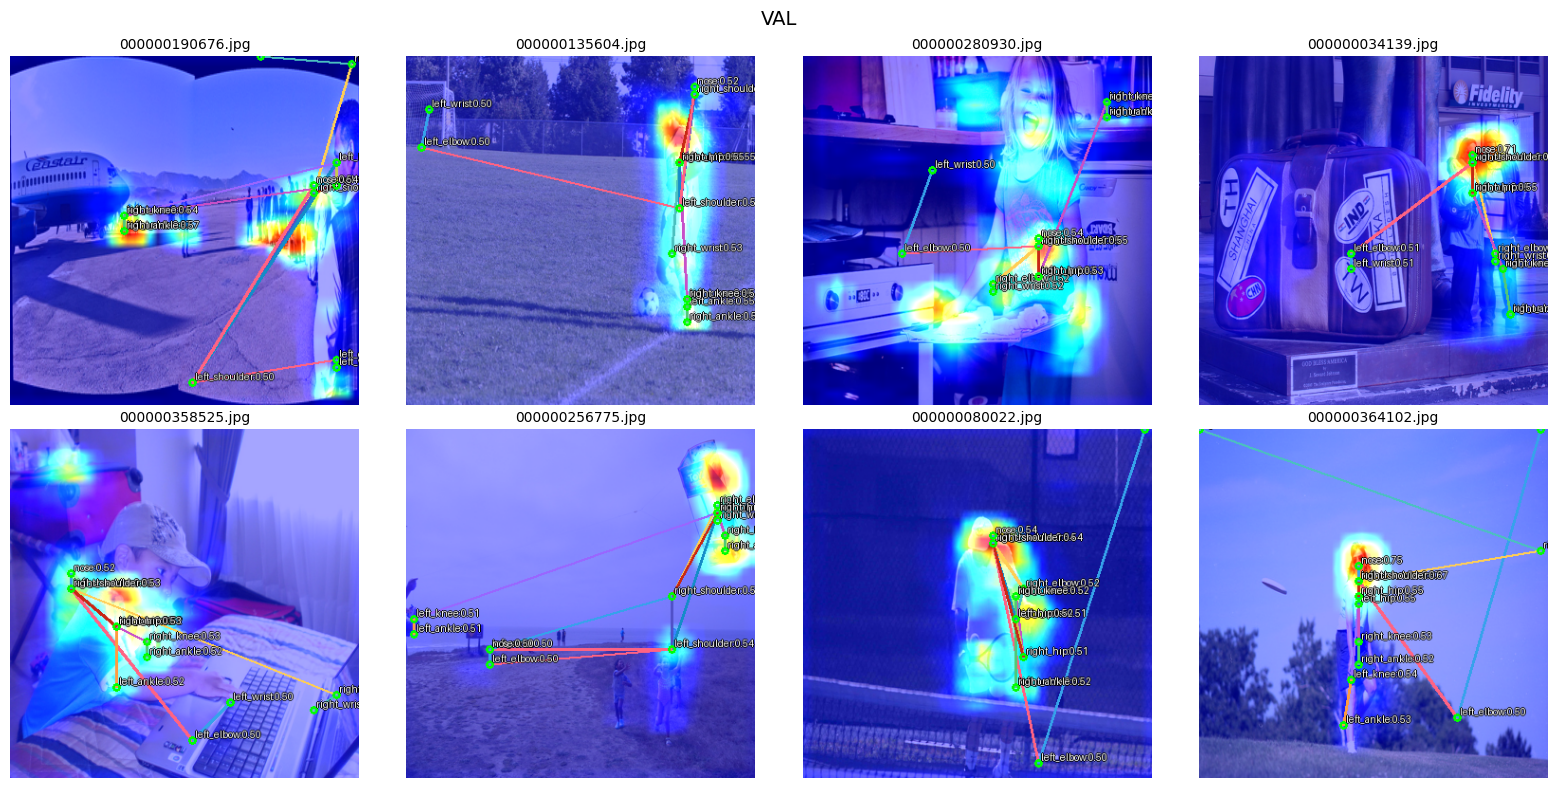

[04/30] tr_loss:0.0151


KeyboardInterrupt: 

In [37]:
# 동작
tr_ds, val_ds, tr_loader, val_loader, m, criterion, opt, scheduler, scaler = build_all()

for ep in range(1, EPOCHS+1):
    tr_loss = train_one_epoch(m, tr_loader, criterion, opt, scaler, ep)
    scheduler.step()
    # 시각화 변경
    visualize_batch_inline(m, val_loader, DEVICE, max_batches=1, max_images=8, th_peak=0.2, nms_k=3,
                           paf_thr=0.05, alpha_hm=0.35, cmap_name='jet', cols=4, epoch=None, title_prefix='VAL')
    # torch.save({'model':m.state_dict(), 'epoch':ep}, os.path.join(OUT_DIR, f'ck_m_{ep:03d}.pt')) # 현재는 확인만 하기 위해 주석
    print(f'[{ep:02d}/{EPOCHS}] tr_loss:{tr_loss:.4f}')